<a href="https://colab.research.google.com/github/takeonakamura6-design/rc/blob/main/GFalhas%20e%20Seguran%C3%A7a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gerência de falhas e Segurança

--- INICIANDO EXPERIMENTO DE GERÊNCIA DE FALHAS ---

RESULTADOS DO MONITORAMENTO:
                     Métrica  Valor
              Total Amostras   1000
Falhas Detectadas (Estático)     20
Falhas Detectadas (Dinâmico)     34


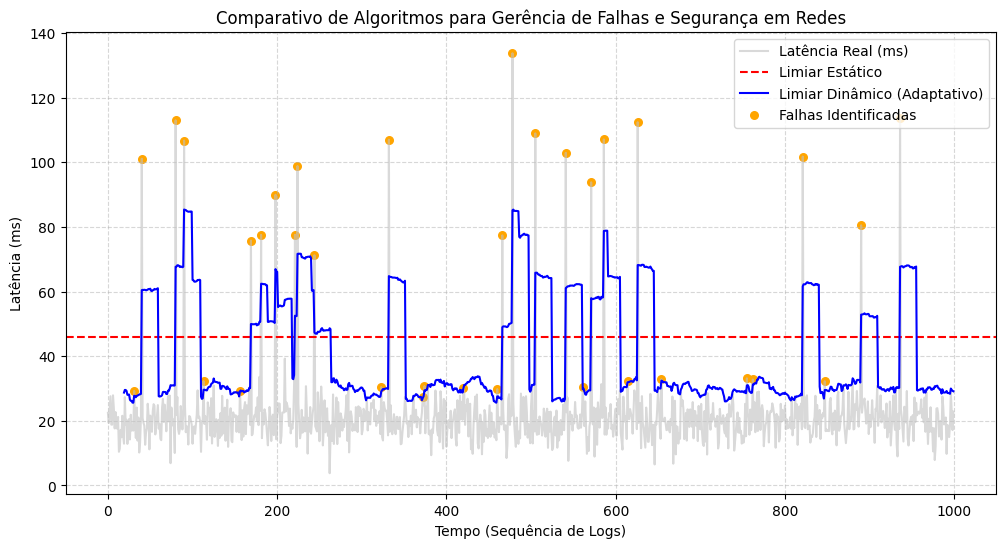


[SUCESSO] O arquivo 'grafico.png' foi gerado para o seu Short Paper.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

def executar_experimento_gerencia_redes():
    """
    Simula e compara algoritmos de gerência de falhas em redes.
    """
    print("--- INICIANDO EXPERIMENTO DE GERÊNCIA DE FALHAS ---")
    np.random.seed(42)

    # 1. Geração de Dados de Latência (1000 logs)
    n_amostras = 1000
    latencia_normal = np.random.normal(loc=20, scale=5, size=n_amostras)

    # 2. Injeção de Falhas (Anomalias) em 2% dos dados
    indices_falha = np.random.choice(range(n_amostras), size=20, replace=False)
    for idx in indices_falha:
        latencia_normal[idx] += np.random.uniform(50, 100)

    df = pd.DataFrame({'latencia_ms': latencia_normal})

    # 3. Algoritmo A: Limiar Estático (Reativo)
    # Define falha como qualquer valor acima de 3 desvios padrão da média global
    limiar_estatico = df['latencia_ms'].mean() + (2 * df['latencia_ms'].std())
    df['falha_estatica'] = df['latencia_ms'] > limiar_estatico

    # 4. Algoritmo B: Limiar Dinâmico (Proativo - Janela Deslizante)
    # Adapta o limiar com base nos últimos 20 logs
    janela = 20
    df['media_movel'] = df['latencia_ms'].rolling(window=janela).mean()
    df['std_movel'] = df['latencia_ms'].rolling(window=janela).std()
    df['limiar_dinamico'] = df['media_movel'] + (2 * df['std_movel'])
    df['falha_dinamica'] = df['latencia_ms'] > df['limiar_dinamico']

    # 5. Consolidação de Resultados
    total_estatico = df['falha_estatica'].sum()
    total_dinamico = df['falha_dinamica'].sum()

    resultados_df = pd.DataFrame({
        'Métrica': ['Total Amostras', 'Falhas Detectadas (Estático)', 'Falhas Detectadas (Dinâmico)'],
        'Valor': [n_amostras, total_estatico, total_dinamico]
    })

    # Exibição da Tabela no Terminal
    print("\nRESULTADOS DO MONITORAMENTO:")
    print(resultados_df.to_string(index=False))

    # 6. Geração do Gráfico Científico
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['latencia_ms'], label='Latência Real (ms)', color='silver', alpha=0.6)
    plt.axhline(y=limiar_estatico, color='red', linestyle='--', label='Limiar Estático')
    plt.plot(df['limiar_dinamico'], color='blue', label='Limiar Dinâmico (Adaptativo)', linewidth=1.5)

    # Destacar falhas detectadas pelo método dinâmico
    falhas_det = df[df['falha_dinamica']]
    plt.scatter(falhas_det.index, falhas_det['latencia_ms'], color='orange', label='Falhas Identificadas', s=30)

    plt.title('Comparativo de Algoritmos para Gerência de Falhas e Segurança em Redes')
    plt.xlabel('Tempo (Sequência de Logs)')
    plt.ylabel('Latência (ms)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # Salvando para o Zenodo/Artigo
    plt.savefig('grafico.png', dpi=300)
    plt.show()
    print("\n[SUCESSO] O arquivo 'grafico.png' foi gerado para o seu Short Paper.")

# Execução
if __name__ == "__main__":
    executar_experimento_gerencia_redes()